In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pingouin as pg

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score,learning_curve
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,f1_score,recall_score,precision_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.neural_network import BernoulliRBM

from sklearn.datasets import load_wine

In [4]:
sns.set_style('darkgrid')
sns.set_palette("deep")

In [5]:
rawdata = load_wine()


In [6]:
X = pd.DataFrame(rawdata.data,columns=rawdata.feature_names)
X

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [7]:
y = pd.DataFrame(rawdata.target,columns=['target'])
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
173,2
174,2
175,2
176,2


In [8]:
fullset = pd.concat([X,y],axis=1)

In [9]:
fullset

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


### EDA Wine

In [10]:
fullset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [11]:
fullset.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


## Analyse Univariée

        count      freq
target                 
1          71  0.398876
0          59  0.331461
2          48  0.269663


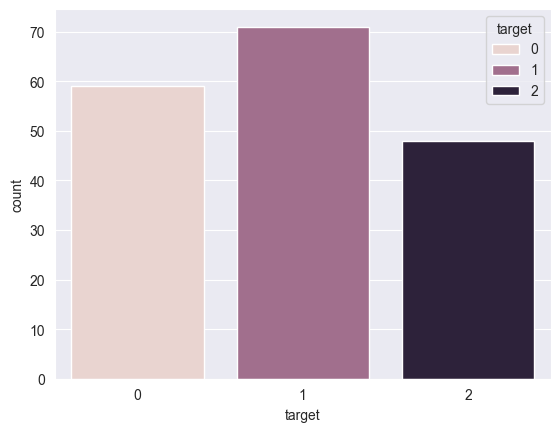

In [12]:
sns.countplot(data=fullset,x='target',hue='target')
print(pd.DataFrame({'count':fullset['target'].value_counts(),
    'freq':fullset['target'].value_counts(normalize=True)}))

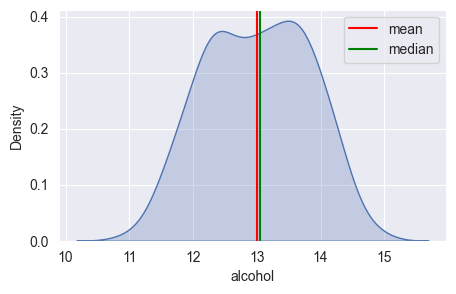

In [13]:
plt.figure(figsize=(5,3))
sns.kdeplot(data=fullset,x='alcohol',fill=True)
plt.axvline(fullset['alcohol'].mean(),color='red',label='mean')
plt.axvline(fullset['alcohol'].median(),color='green',label='median')
plt.legend()

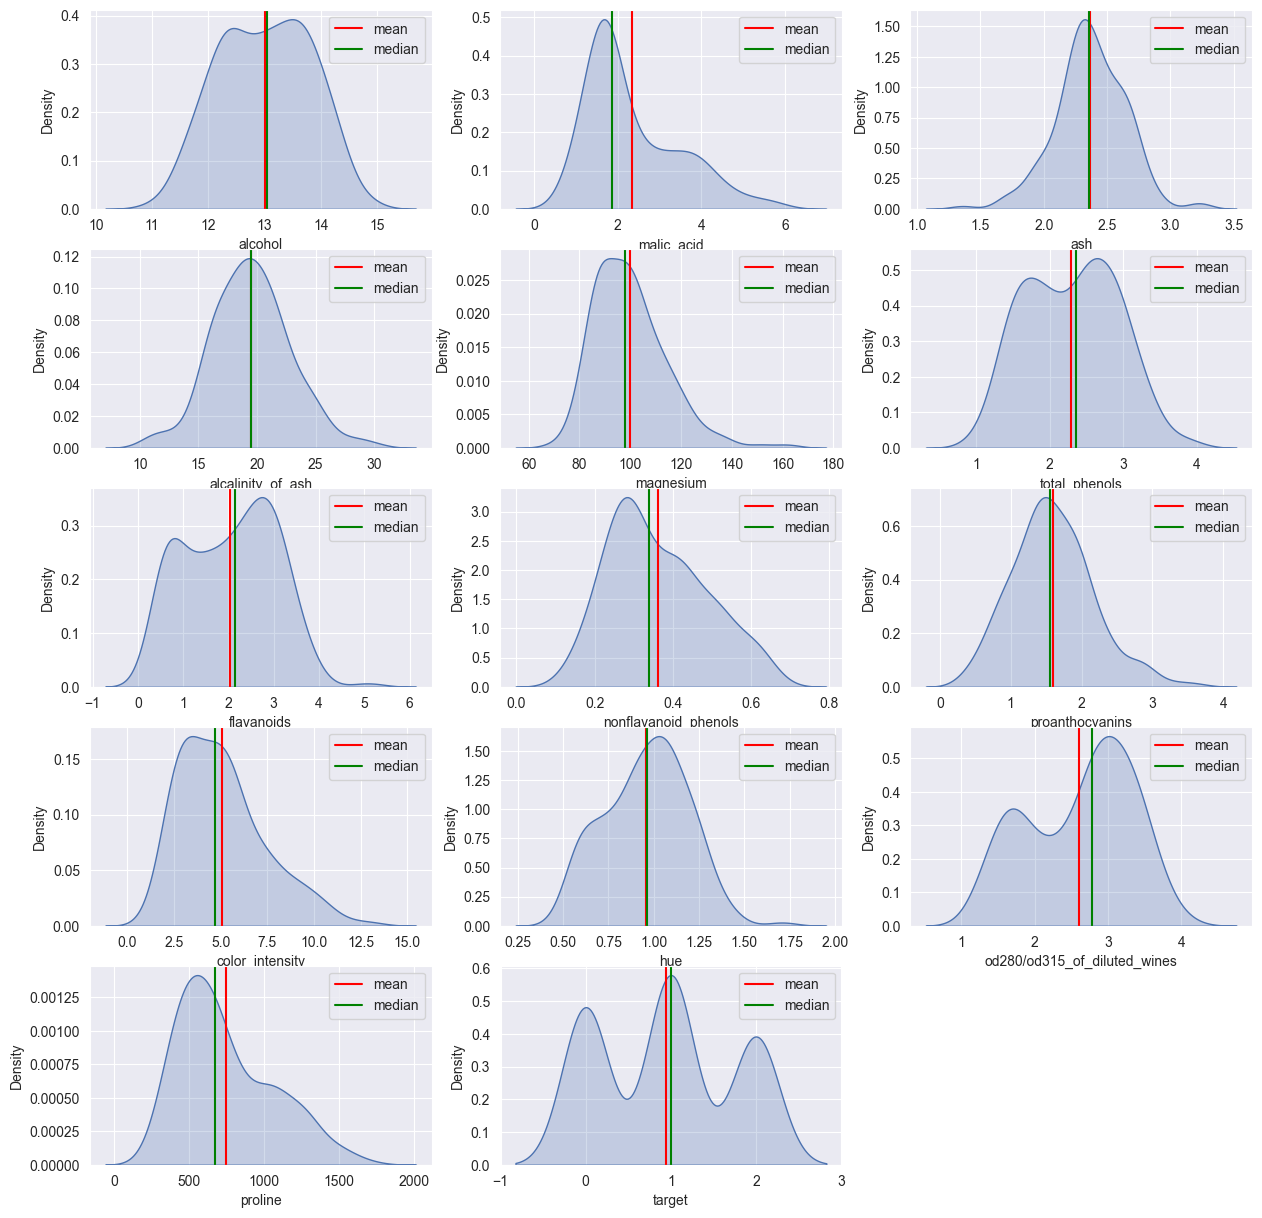

In [14]:
plt.figure(figsize=(15,15))
for i,col in enumerate(fullset.columns):
    plt.subplot(5,3,i+1)
    sns.kdeplot(data=fullset,x=col,fill=True)
    plt.axvline(fullset[col].mean(),color='red',label='mean')
    plt.axvline(fullset[col].median(),color='green',label='median')
    plt.legend()
plt.show()

## Analyse Bivariée

In [15]:
fullset.loc[fullset['target'] == 0]['alcohol']

0     14.23
1     13.20
2     13.16
3     14.37
4     13.24
5     14.20
6     14.39
7     14.06
8     14.83
9     13.86
10    14.10
11    14.12
12    13.75
13    14.75
14    14.38
15    13.63
16    14.30
17    13.83
18    14.19
19    13.64
20    14.06
21    12.93
22    13.71
23    12.85
24    13.50
25    13.05
26    13.39
27    13.30
28    13.87
29    14.02
30    13.73
31    13.58
32    13.68
33    13.76
34    13.51
35    13.48
36    13.28
37    13.05
38    13.07
39    14.22
40    13.56
41    13.41
42    13.88
43    13.24
44    13.05
45    14.21
46    14.38
47    13.90
48    14.10
49    13.94
50    13.05
51    13.83
52    13.82
53    13.77
54    13.74
55    13.56
56    14.22
57    13.29
58    13.72
Name: alcohol, dtype: float64

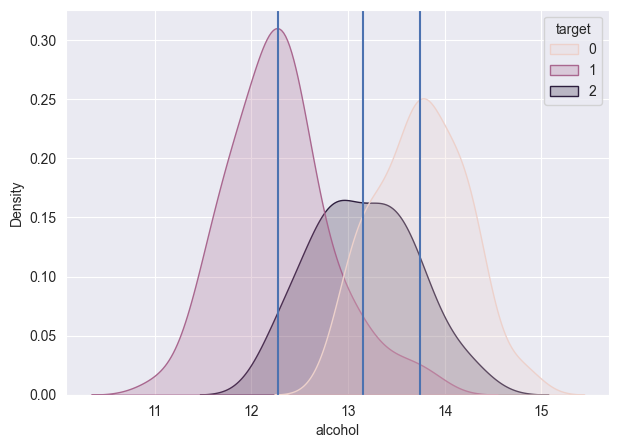

In [16]:
plt.figure(figsize=(7,5))
sns.kdeplot(data=fullset,x='alcohol',hue='target',fill=True)
plt.axvline(fullset.loc[fullset['target'] == 0]['alcohol'].mean())
plt.axvline(fullset.loc[fullset['target'] == 1]['alcohol'].mean())
plt.axvline(fullset.loc[fullset['target'] == 2]['alcohol'].mean())

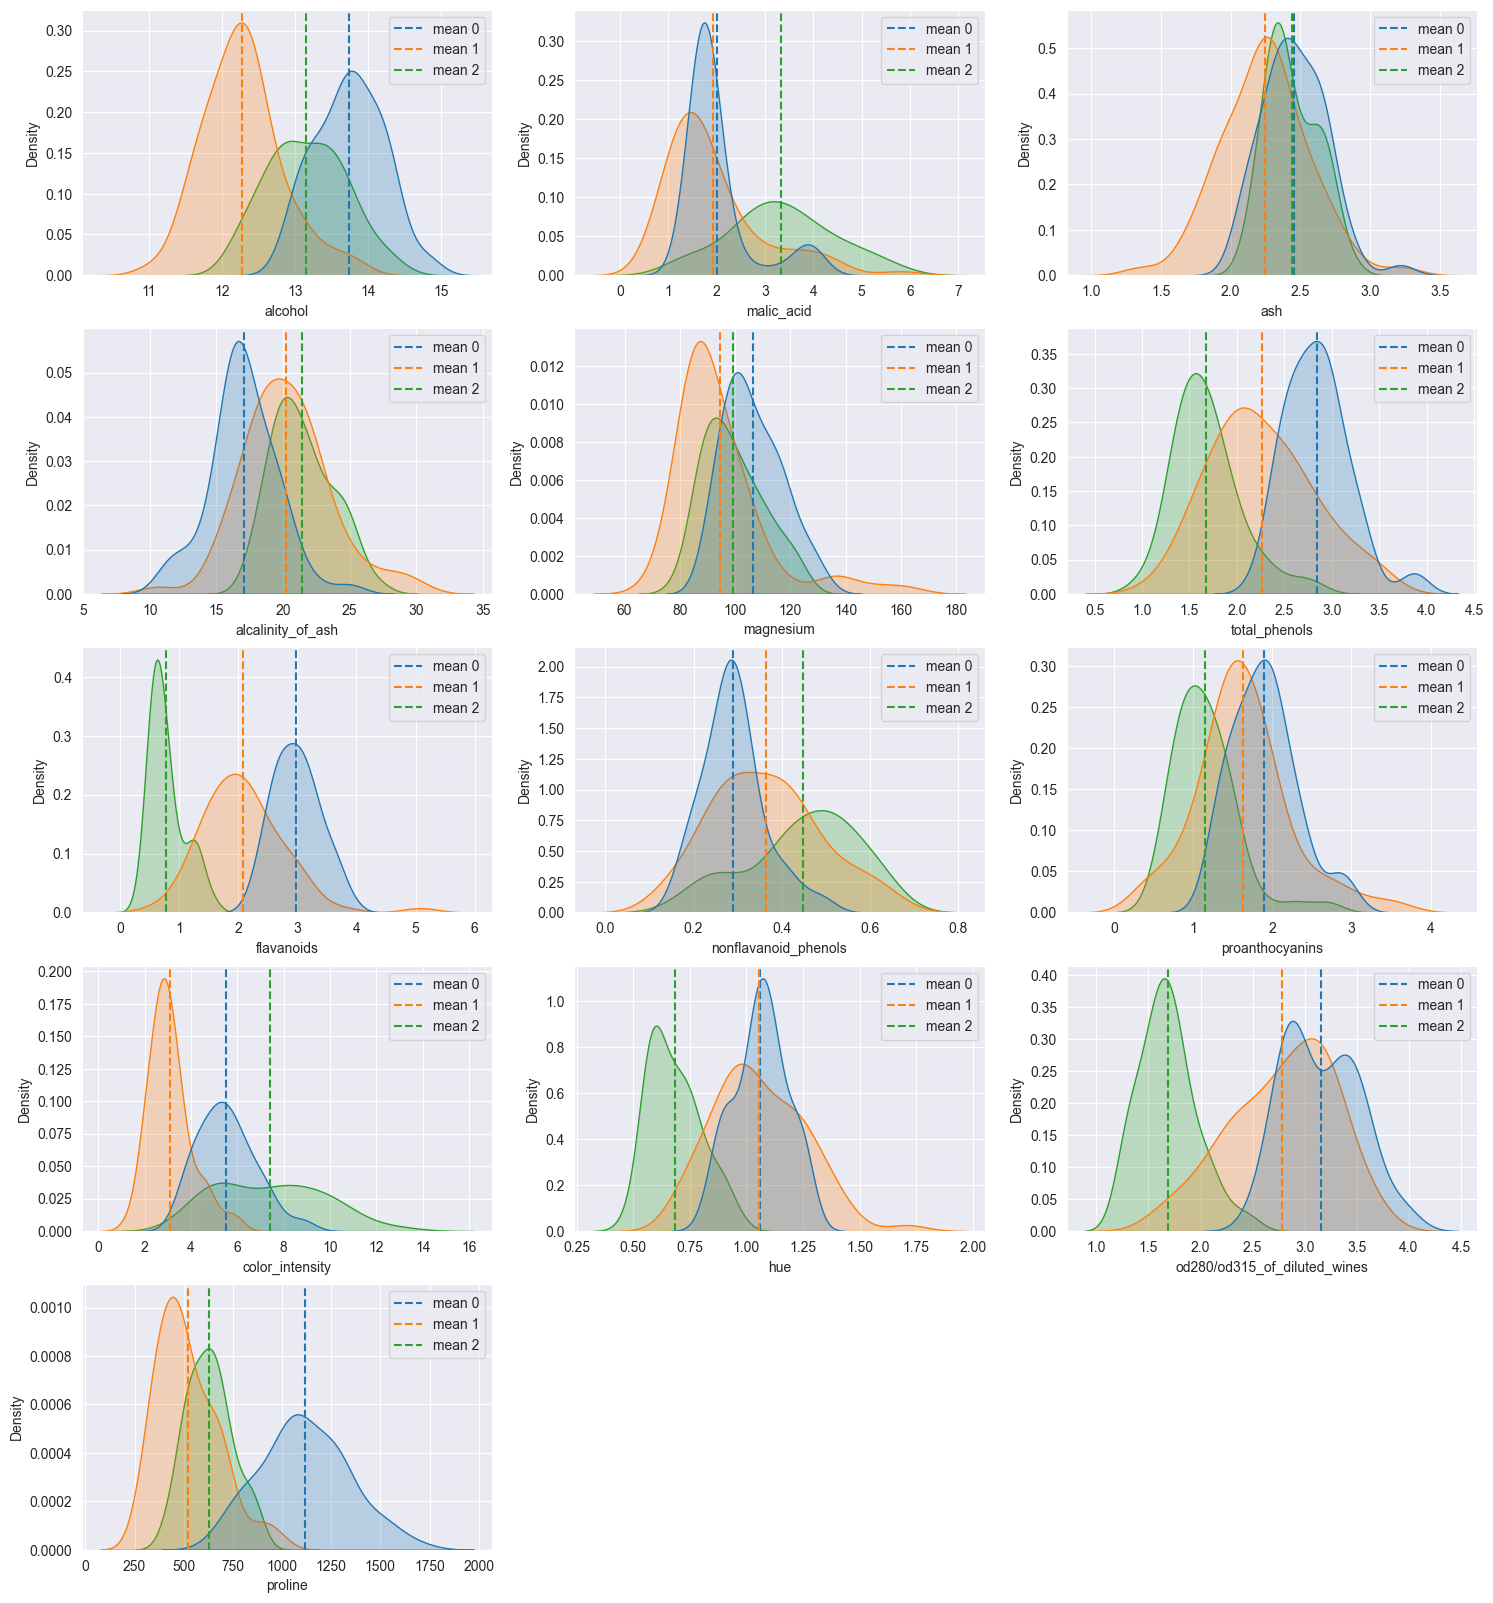

In [17]:
palette = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure(figsize=(18,20))
for i, col in enumerate(fullset.columns.drop('target')):

    plt.subplot(5,3,i+1)
    sns.kdeplot(data=fullset,x=col,hue='target',fill=True,palette=palette)
    plt.axvline(fullset.loc[fullset['target'] == 0][col].mean(),label = 'mean 0',color = palette[0],linestyle = '--')
    plt.axvline(fullset.loc[fullset['target'] == 1][col].mean(),label = 'mean 1',color = palette[1],linestyle = '--')
    plt.axvline(fullset.loc[fullset['target'] == 2][col].mean(),label = 'mean 2',color = palette[2],linestyle = '--')
    plt.legend()

plt.show()

## Analyse Multivariée ( Corrélation )

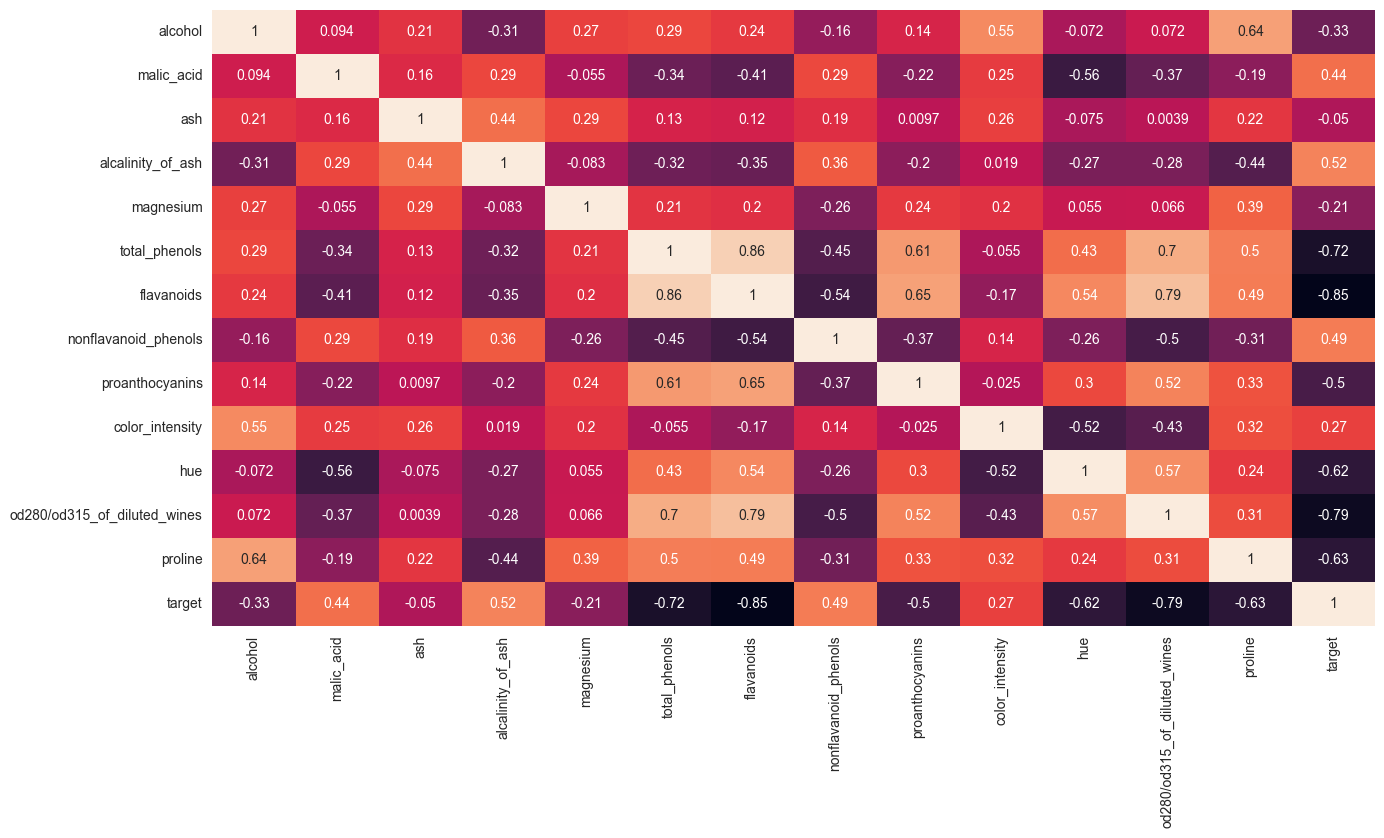

In [18]:
plt.figure(figsize=(15,8))
sns.heatmap(fullset.corr(),cbar=False,annot=True)
plt.show()

Ici notre matrice de corrélation nous donnes une idées de la relation entre nos variables, le soucis c'est que notre target est en réalité une variable de type catégorielle qui a été encodée (0,1,2), le fait d'encoder une variable induit une relation d'ordre dans nos target ( 0 < 1 < 2), hors il n'éxiste pas d'ordre de grandeur entre nos classes. Il faut donc faire attention a l'interprétation de notre matrice de corrélation et pousser l'analyse plus loin pour confirmé nos hypothèses.

## Information Mutuelle 

In [19]:
X = fullset.drop('target', axis=1) # Features
y = fullset['target'] # Target

In [20]:
mi_scores = mutual_info_classif(X, y)
mi_series = pd.Series(mi_scores, index=X.columns)
print(mi_series.sort_values(ascending=False))

flavanoids                      0.671230
proline                         0.577281
color_intensity                 0.551578
od280/od315_of_diluted_wines    0.512724
hue                             0.469301
alcohol                         0.465903
total_phenols                   0.420294
proanthocyanins                 0.285384
malic_acid                      0.282777
alcalinity_of_ash               0.225642
magnesium                       0.193701
nonflavanoid_phenols            0.108235
ash                             0.053397
dtype: float64


 L'information mutuelle est une méthode non paramétrique qui ne suppose pas de relation linéaire entre les variables. Elle mesure simplement la dépendance entre deux variables, qu'elles soient continues ou catégorielles.

## Tests Statistiques

### Normalitée 

In [21]:
for col in list(fullset.drop(columns='target').columns):
    display(pg.normality(data=fullset,dv=col,group='target'))

,W,pval,normal
target,,,
0,0.980894,0.479068,True
1,0.972052,0.113961,True
2,0.981468,0.640839,True


,W,pval,normal
target,,,
0,0.646978,1.203394e-10,False
1,0.833878,1.839853e-07,False
2,0.983720,7.377182e-01,True


,W,pval,normal
target,,,
0,0.970156,0.155563,True
1,0.986039,0.619761,True
2,0.960846,0.109227,True


,W,pval,normal
target,,,
0,0.973147,0.216086,True
1,0.968778,0.073974,True
2,0.959762,0.098742,True


,W,pval,normal
target,,,
0,0.964859,8.617381e-02,True
1,0.779031,5.791919e-09,False
2,0.949630,3.865300e-02,False


...

,W,pval,normal
target,,,
0,0.955786,0.031498,False
1,0.951568,0.008146,False
2,0.887202,0.000249,False


,W,pval,normal
target,,,
0,0.968195,0.125094,True
1,0.931748,0.000819,False
2,0.958494,0.087752,True


,W,pval,normal
target,,,
0,0.969877,0.150822,True
1,0.977273,0.224930,True
2,0.946163,0.028188,False


,W,pval,normal
target,,,
0,0.963903,0.077446,True
1,0.970181,0.089040,True
2,0.957910,0.083107,True


,W,pval,normal
target,,,
0,0.981852,0.523241,True
1,0.938680,0.001774,False
2,0.976941,0.458495,True


Les distributions ne respectent pas l'hypothèse de normalité.

### Homoscédasticité 

In [22]:
for col in list(fullset.drop(columns='target').columns):
    display(pg.homoscedasticity(data=fullset,dv=col,group='target'))

,W,pval,equal_var
levene,0.599789,0.550052,True


,W,pval,equal_var
levene,6.357927,0.00216,False


,W,pval,equal_var
levene,4.211763,0.01635,False


,W,pval,equal_var
levene,2.936396,0.055676,True


,W,pval,equal_var
levene,0.65692,0.519719,True


...

,W,pval,equal_var
levene,2.943385,0.055301,True


,W,pval,equal_var
levene,31.257111,2.471654e-12,False


,W,pval,equal_var
levene,11.846657,0.000015,False


,W,pval,equal_var
levene,10.710731,0.000041,False


,W,pval,equal_var
levene,8.513307,0.000296,False


Non respect de l'hypothèse d'homoscédasticité => hétéroscédasticité => ANOVA de Welch

### Welch Anova

In [23]:
type(pg.welch_anova(data=fullset,dv=col,between='target'))

pandas.core.frame.DataFrame

In [24]:
for col in list(fullset.drop(columns='target').columns):
    print(col)
    display(pg.welch_anova(data=fullset,dv=col,between='target'))
    print('\n')

alcohol


,Source,ddof1,ddof2,F,p-unc,np2
0,target,2,109.926297,139.413321,7.059126e-31,0.606879




malic_acid


,Source,ddof1,ddof2,F,p-unc,np2
0,target,2,104.893918,30.526779,3.560400e-11,0.296869




ash


...

,Source,ddof1,ddof2,F,p-unc,np2
0,target,2,114.793113,162.098693,3.666494e-34,0.536588




od280/od315_of_diluted_wines


,Source,ddof1,ddof2,F,p-unc,np2
0,target,2,116.660595,318.796365,5.222355e-48,0.684653




proline


,Source,ddof1,ddof2,F,p-unc,np2
0,target,2,111.803414,153.840757,7.903389e-33,0.703812


L'ANOVA de Welch semble confirmer les hypothèses de l'information mutuelle. 

En résumé et au vue des différents tests statistiques, nous devrions nous orienté vers un modele d'apprentissage de type non paramétrique. 

Liste non exhaustive :

- KNNeighbor
- DecisionForestClassifier
- SVM ( support vector machine )

----------------------------------------------------------------------------------------------------------------------------------------------

# ML Wine

X (features) et y (target) ont été défini plus haut.

Commencons par splitter notre dataset.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

Entrainement d'un modele d'arbre de décision.

In [26]:
treemodel = DecisionTreeClassifier()
treemodel.fit(X_train,y_train)

y_pred_tree = treemodel.predict(X_test)

accuracy_score(y_test,y_pred_tree)

0.8888888888888888

Entrainement d'un modele KNNeighbor

In [27]:
knnmodel = KNeighborsClassifier()
knnmodel.fit(X_train,y_train)

y_pred_knn = knnmodel.predict(X_test)

accuracy_score(y_test,y_pred_knn)

0.6666666666666666

Entrainement d'un modele support vecteur machine

In [28]:
svmmodel = SVC()
svmmodel.fit(X_train,y_train)

y_pred_svm = svmmodel.predict(X_test)

accuracy_score(y_test,y_pred_svm)

0.6944444444444444

## Testons avec une crossvalidation 

In [29]:
tree_cross_score = cross_val_score(treemodel,X_train,y_train,cv=5,scoring='accuracy')
tree_cross_score.mean()

np.float64(0.8805418719211822)

In [30]:
knn_cross_score = cross_val_score(knnmodel,X_train,y_train,cv=5,scoring='accuracy')
knn_cross_score.mean()

np.float64(0.6763546798029557)

In [31]:
svm_cross_score = cross_val_score(svmmodel,X_train,y_train,cv=5,scoring='accuracy')
svm_cross_score.mean()

np.float64(0.6761083743842364)

Il semblerait que le DecisionTreeClassifier nous donne les meilleurs résultats, nous allons donc continuer avec celui la. Cepandant nous n'avons pas tester toute les possibilités, une approche avec GridSearchCV pourrait etre intéréssante afin de confirmer notre hypothèse.

## Optimisation de notre arbre de décision grace a GridsearchCV

In [32]:
params = {'criterion':['gini','entropy','log_loss'],
          'max_depth':[i+1 for i in range(11)]}

grid = GridSearchCV(estimator=treemodel,param_grid=params,cv=5,scoring='accuracy')

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]},
             scoring='accuracy')

In [33]:
final_model = grid.best_estimator_

In [34]:
y_pred_final_model =  final_model.predict(X_test)

In [35]:
accuracy_score(y_test,y_pred_final_model)

0.9166666666666666

<Axes: >

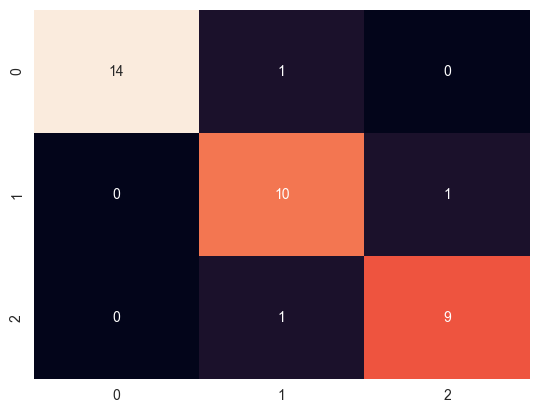

In [41]:
sns.heatmap(confusion_matrix(y_test,y_pred_final_model),annot=True,cbar=False)

## Introduction de nouvelles mesures pour vérifier l'efficacité d'un modèle.

Métriques de Classification

a. Accuracy (Exactitude)

    Définition : Proportion de prédictions correctes par rapport à l'ensemble des prédictions.
    Formule : (Vrai Positifs+Vrai Négatifs)/Total des Prédictions
    Usage : Utile si les classes sont équilibrées, mais peut être trompeur avec des classes déséquilibrées.

b. Precision (Précision)

    Définition : Proportion de vraies prédictions positives parmi toutes les prédictions positives faites par le modèle.
    Formule : Précision=Vrai Positifs/(Vrai Positifs+Faux Positifs)
    Usage : Utilisée lorsque les faux positifs sont coûteux (par exemple, spam detection).

c. Recall (Rappel ou Sensibilité)

    Définition : Proportion de vrais positifs capturés parmi tous les vrais positifs réels.
    Formule : Rappel=Vrai Positifs/(Vrai Positifs+Faux Négatifs)
    Usage : Important lorsque manquer des vrais positifs est coûteux (par exemple, détection de maladie).

d. F1-Score

    Définition : Moyenne harmonique de la précision et du rappel. Représente un bon compromis entre les deux.
    Formule : F1= 2 × (Précision X Rappel / Précision + Rappel) 
    Usage : Utile lorsque vous devez équilibrer précision et rappel, surtout en cas de classes déséquilibrées.

## Classification Report

In [37]:
print(classification_report(y_test,y_pred_final_model))

              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.83      0.91      0.87        11
           2       0.90      0.90      0.90        10

    accuracy                           0.92        36
   macro avg       0.91      0.91      0.91        36
weighted avg       0.92      0.92      0.92        36



## Learning Curve 

In [49]:
X_train

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
86,12.16,1.61,2.31,22.8,90.0,1.78,1.69,0.43,1.56,2.45,1.33,2.26,495.0
42,13.88,1.89,2.59,15.0,101.0,3.25,3.56,0.17,1.70,5.43,0.88,3.56,1095.0
162,12.85,3.27,2.58,22.0,106.0,1.65,0.60,0.60,0.96,5.58,0.87,2.11,570.0
59,12.37,0.94,1.36,10.6,88.0,1.98,0.57,0.28,0.42,1.95,1.05,1.82,520.0
76,13.03,0.90,1.71,16.0,86.0,1.95,2.03,0.24,1.46,4.60,1.19,2.48,392.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
29,14.02,1.68,2.21,16.0,96.0,2.65,2.33,0.26,1.98,4.70,1.04,3.59,1035.0
23,12.85,1.60,2.52,17.8,95.0,2.48,2.37,0.26,1.46,3.93,1.09,3.63,1015.0
79,12.70,3.87,2.40,23.0,101.0,2.83,2.55,0.43,1.95,2.57,1.19,3.13,463.0


In [85]:
# Calcul des learning curves
train_sizes, train_scores, test_scores = learning_curve(final_model, X_train, y_train, cv=5, train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy')

In [86]:
# Calcul des moyennes et écarts-types des scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

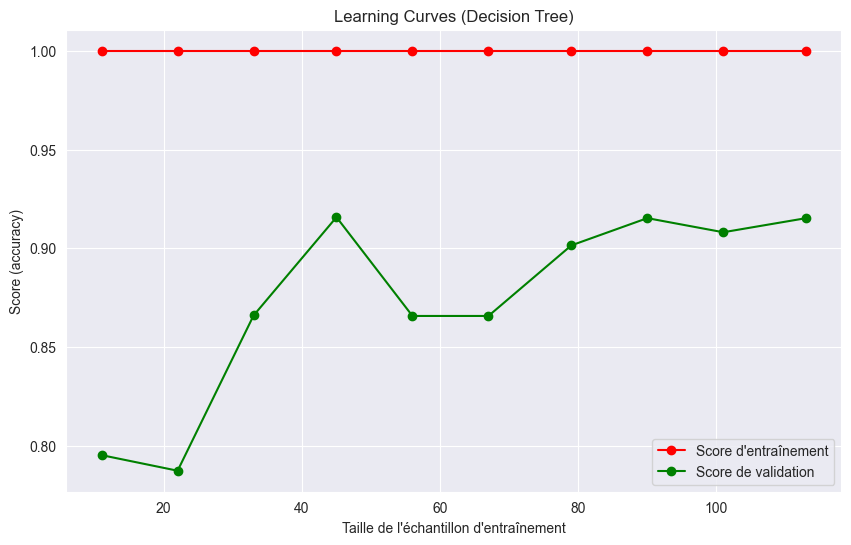

In [87]:
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Score d'entraînement")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Score de validation")
plt.title('Learning Curves (Decision Tree)')
plt.xlabel('Taille de l\'échantillon d\'entraînement')
plt.ylabel('Score (accuracy)')
plt.legend(loc="best")
plt.grid(True)
plt.show()

Interprétation de la courbe :

    Sous-ajustement (underfitting): Si les scores de validation et d'entraînement sont bas, cela indique que le modèle est sous-ajusté (il ne s'ajuste pas bien aux données d'entraînement).
    Sur-ajustement (overfitting): Si les scores d'entraînement sont élevés mais ceux de validation sont faibles, cela montre que le modèle sur-apprend (sur-ajustement).
    Bon ajustement : Lorsque les courbes de validation et d'entraînement convergent, cela indique que le modèle généralise bien.